In [2]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import numpy as np



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/behaviour_detection.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/behaviour_detection.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/behaviour_detection.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/behaviour_detection.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/behaviour_detection.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df[df['interaction_group'] == 'first'].copy()

si = df[df["Condition"].str.startswith("SI")].copy()
gh = df[df["Condition"].str.startswith("GH")].copy()

# Optional: remove SI/GH prefix so plot labels are cleaner
si["feeding_condition"] = si["Condition"].str.replace("SI ", "", regex=False)
gh["feeding_condition"] = gh["Condition"].str.replace("GH ", "", regex=False)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14467/413164220.py:19: DtypeWarning: Columns (97,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/behaviour_detection.csv')
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14467/413164220.py:26: DtypeWarning: Columns (97,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')


KeyError: 'interaction_number'

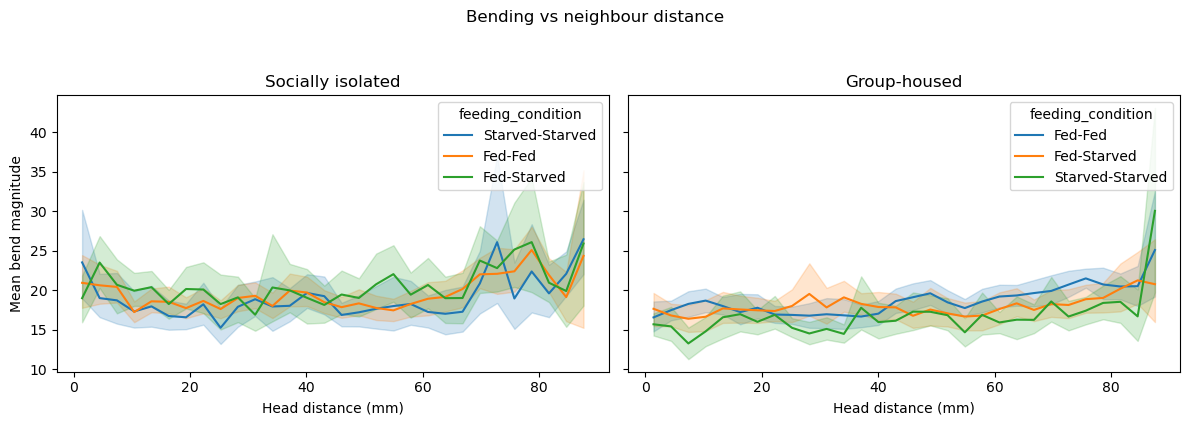

In [ ]:
def make_binned_per_file(data, n_bins=30):
    df_plot = data[
        (data["head_distance"].notna()) &
        (data["bend_magnitude"].notna())
    ].copy()

    df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=n_bins)
    df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid).astype(float)

    binned_per_file = (
        df_plot
        .groupby(["file", "feeding_condition", "distance_mid"], observed=True)["bend_magnitude"]
        .mean()
        .reset_index()
    )

    return binned_per_file


si_binned = make_binned_per_file(si)
gh_binned = make_binned_per_file(gh)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# SI plot on left
sns.lineplot(
    data=si_binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="feeding_condition",
    errorbar=("ci", 95),
    estimator="mean",
    ax=axes[0]
)

axes[0].set_title("Socially isolated")
axes[0].set_xlabel("Head distance (mm)")
axes[0].set_ylabel("Mean bend magnitude")

# GH plot on right
sns.lineplot(
    data=gh_binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="feeding_condition",
    errorbar=("ci", 95),
    estimator="mean",
    ax=axes[1]
)

axes[1].set_title("Group-housed")
axes[1].set_xlabel("Head distance (mm)")
axes[1].set_ylabel("")

plt.suptitle("Bending vs neighbour distance", y=1.05)
plt.tight_layout()
plt.show()




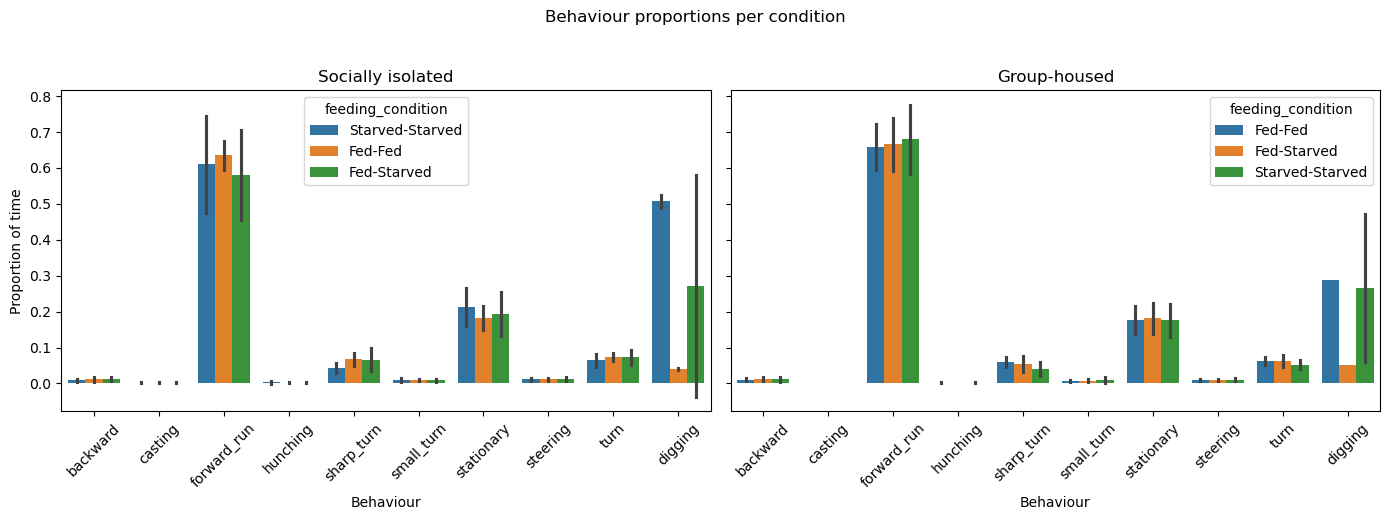

In [ ]:
# ---------------- SI ----------------

si_total_frames = (
    si.groupby("file")
    .size()
    .reset_index(name="total_frames")
)

si_behaviour_frames = (
    si.groupby(["file", "feeding_condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

si_prop = si_behaviour_frames.merge(si_total_frames, on="file")

si_prop["proportion"] = (
    si_prop["n_frames"] / si_prop["total_frames"]
)


# ---------------- GH ----------------

gh_total_frames = (
    gh.groupby("file")
    .size()
    .reset_index(name="total_frames")
)

gh_behaviour_frames = (
    gh.groupby(["file", "feeding_condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

gh_prop = gh_behaviour_frames.merge(gh_total_frames, on="file")

gh_prop["proportion"] = (
    gh_prop["n_frames"] / gh_prop["total_frames"]
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.barplot(
    data=si_prop,
    x="behaviour",
    y="proportion",
    hue="feeding_condition",
    errorbar="sd",
    ax=axes[0]
)

axes[0].set_title("Socially isolated")
axes[0].set_xlabel("Behaviour")
axes[0].set_ylabel("Proportion of time")
axes[0].tick_params(axis="x", rotation=45)


sns.barplot(
    data=gh_prop,
    x="behaviour",
    y="proportion",
    hue="feeding_condition",
    errorbar="sd",
    ax=axes[1]
)

axes[1].set_title("Group-housed")
axes[1].set_xlabel("Behaviour")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Behaviour proportions per condition", y=1.03)
plt.tight_layout()
plt.show()

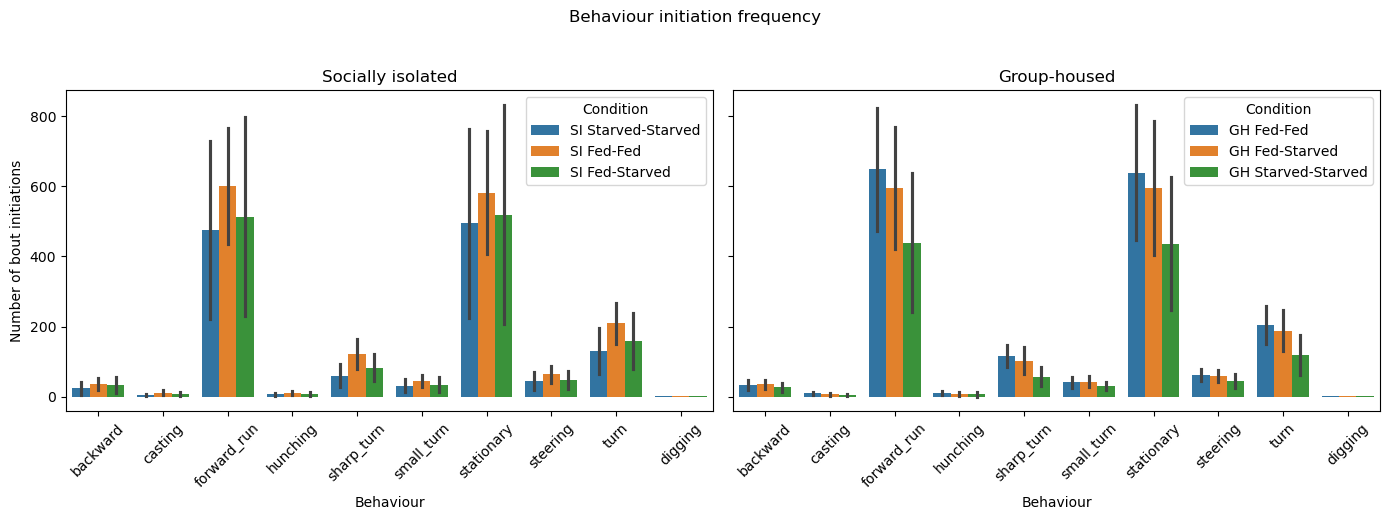

In [ ]:
# ---------------- SI ----------------

si = si.sort_values(["file", "track_id", "frame"]).copy()

si["prev_behaviour"] = (
    si.groupby(["file", "track_id"])["behaviour"]
    .shift()
)

si["is_initiation"] = si["behaviour"] != si["prev_behaviour"]

si_bout_counts = (
    si[si["is_initiation"]]
    .groupby(["file", "Condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)


# ---------------- GH ----------------

gh = gh.sort_values(["file", "track_id", "frame"]).copy()

gh["prev_behaviour"] = (
    gh.groupby(["file", "track_id"])["behaviour"]
    .shift()
)

gh["is_initiation"] = gh["behaviour"] != gh["prev_behaviour"]

gh_bout_counts = (
    gh[gh["is_initiation"]]
    .groupby(["file", "Condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# SI plot
sns.barplot(
    data=si_bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="Condition",
    errorbar="sd",
    ax=axes[0]
)

axes[0].set_title("Socially isolated")
axes[0].set_xlabel("Behaviour")
axes[0].set_ylabel("Number of bout initiations")
axes[0].tick_params(axis="x", rotation=45)


# GH plot
sns.barplot(
    data=gh_bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="Condition",
    errorbar="sd",
    ax=axes[1]
)

axes[1].set_title("Group-housed")
axes[1].set_xlabel("Behaviour")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Behaviour initiation frequency", y=1.03)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_46288/3988458769.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


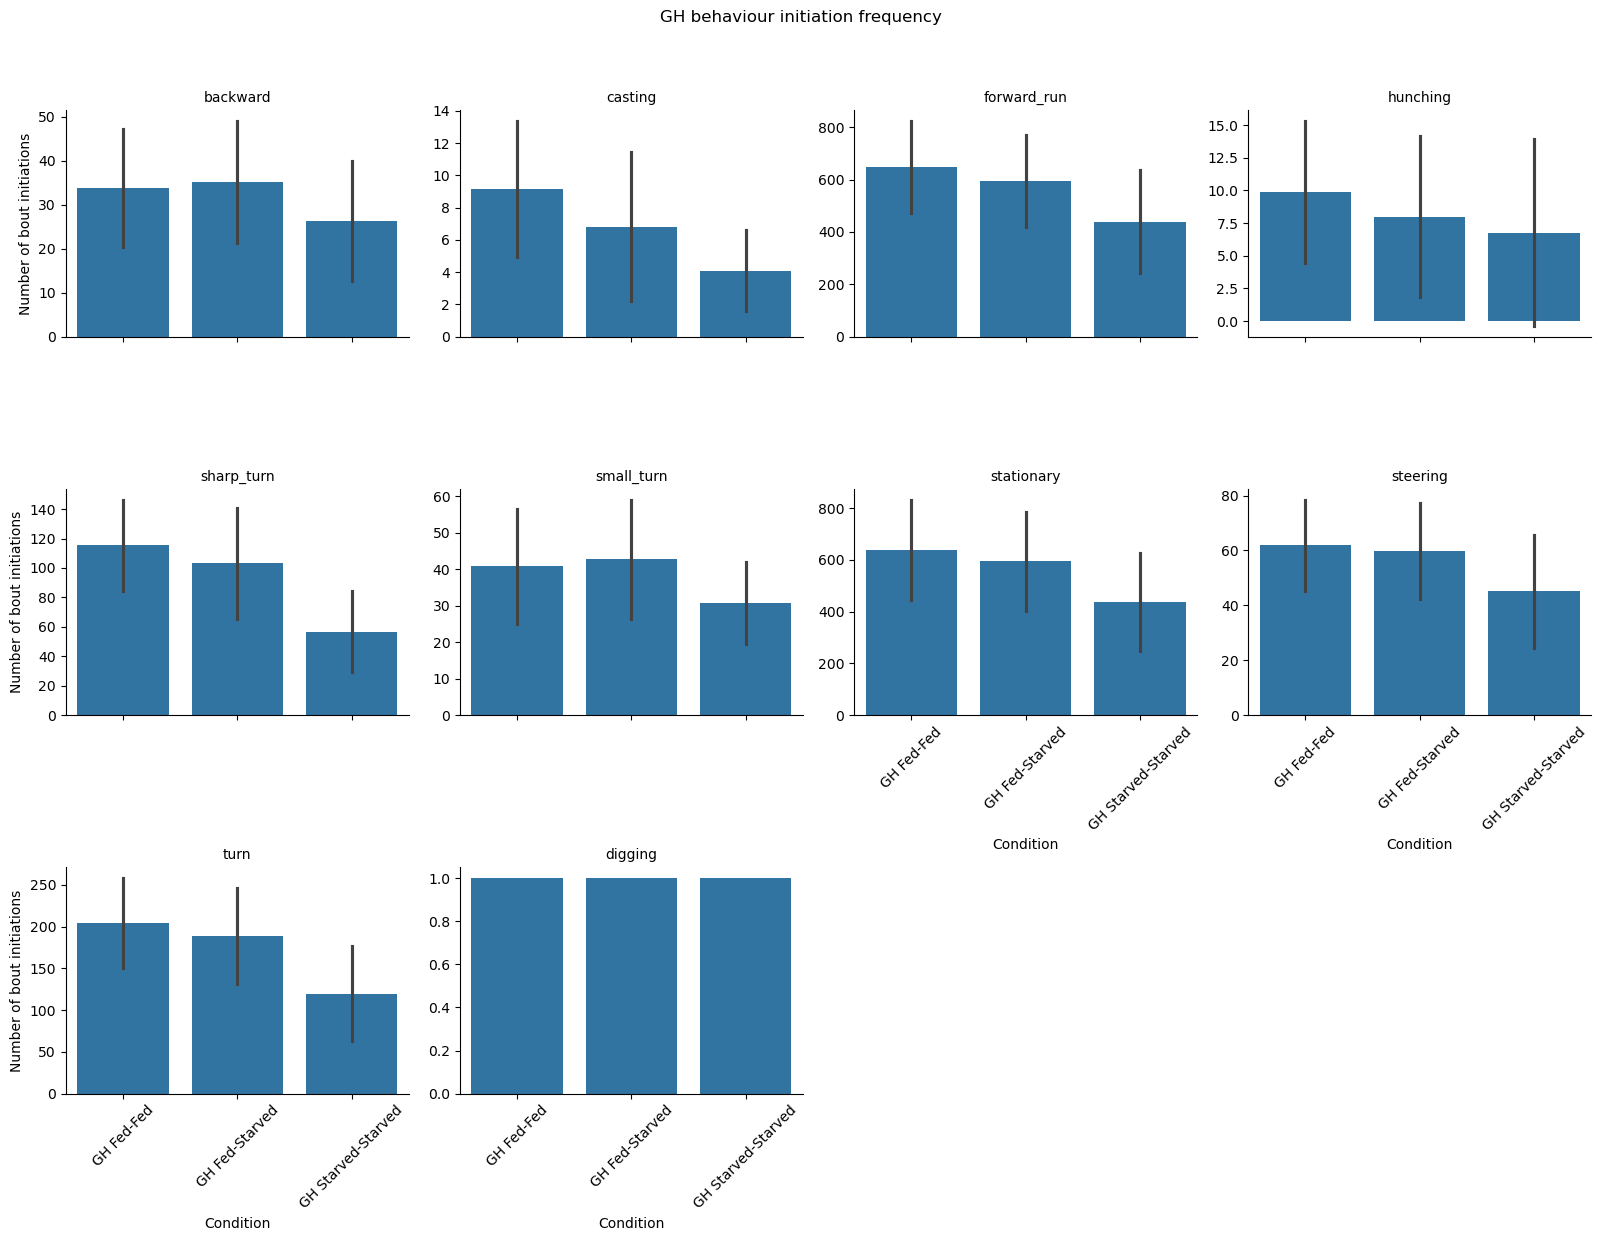

In [ ]:
# ---------------- GH: one plot per behaviour ----------------

g = sns.catplot(
    data=gh_bout_counts,
    x="Condition",
    y="n_bouts",
    col="behaviour",
    kind="bar",
    errorbar="sd",
    col_wrap=4,
    height=4,
    aspect=1,
    sharey=False
)

g.set_axis_labels("Condition", "Number of bout initiations")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("GH behaviour initiation frequency", y=1.03)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_46288/17326912.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


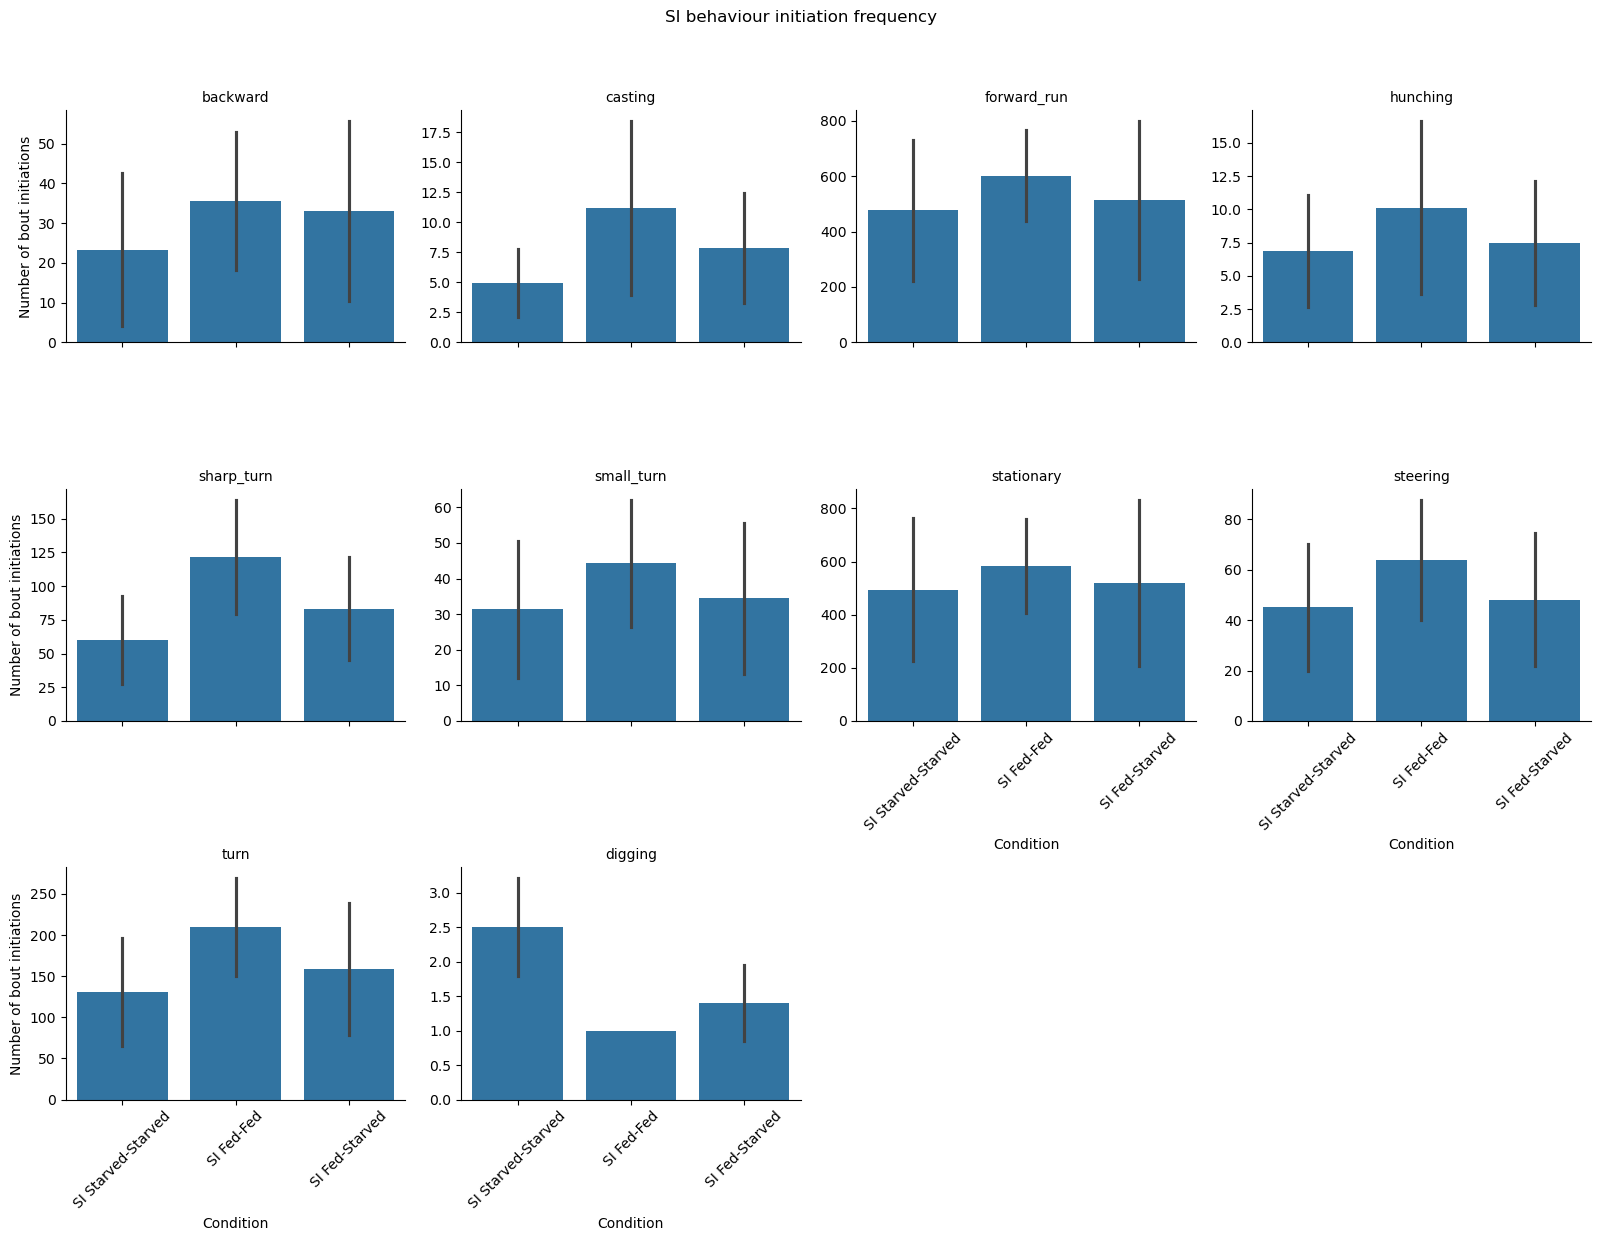

In [ ]:
# ---------------- SI: one plot per behaviour ----------------

g = sns.catplot(
    data=si_bout_counts,
    x="Condition",
    y="n_bouts",
    col="behaviour",
    kind="bar",
    errorbar="sd",
    col_wrap=4,
    height=4,
    aspect=1,
    sharey=False
)

g.set_axis_labels("Condition", "Number of bout initiations")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("SI behaviour initiation frequency", y=1.03)
plt.tight_layout()
plt.show()

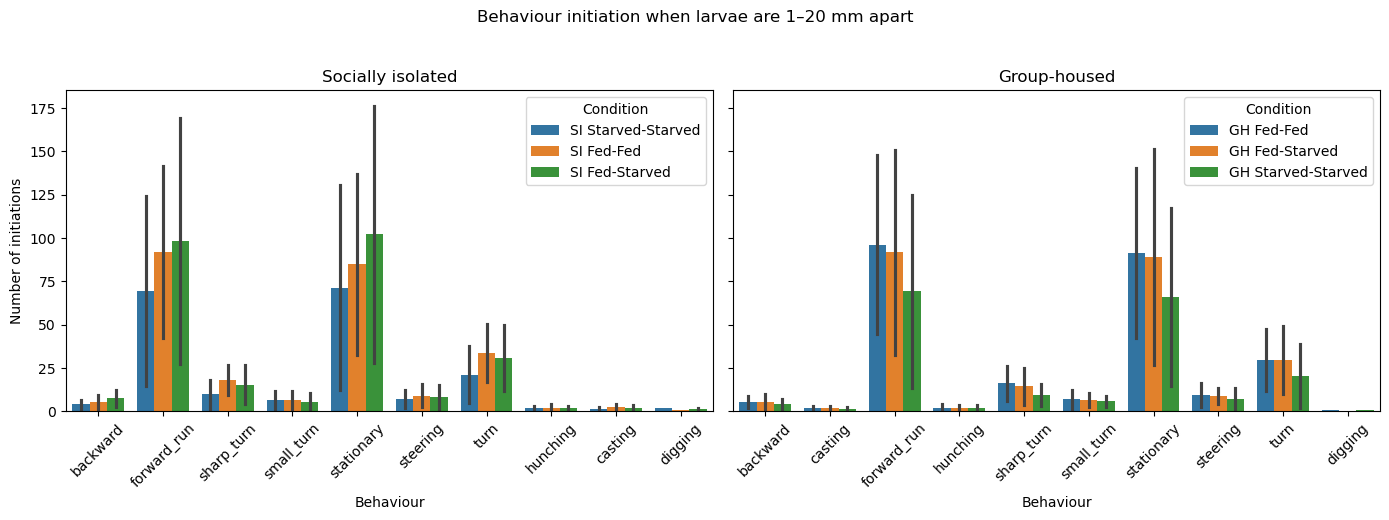

In [ ]:
# ---------------- SI close-distance data ----------------

si_close = si[
    (si["closest_node_node_distance"].notna()) &
    (si["closest_node_node_distance"] >= 1) &
    (si["closest_node_node_distance"] <= 20)
].copy()

si_close = si_close.sort_values(["file", "track_id", "frame"]).copy()

si_close["prev_behaviour"] = (
    si_close.groupby(["file", "track_id"])["behaviour"]
    .shift()
)

si_close["is_initiation"] = (
    si_close["prev_behaviour"].notna() &
    (si_close["behaviour"] != si_close["prev_behaviour"])
)

si_bout_counts_close = (
    si_close[si_close["is_initiation"]]
    .groupby(["file", "Condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)


# ---------------- GH close-distance data ----------------

gh_close = gh[
    (gh["closest_node_node_distance"].notna()) &
    (gh["closest_node_node_distance"] >= 1) &
    (gh["closest_node_node_distance"] <= 20)
].copy()

gh_close = gh_close.sort_values(["file", "track_id", "frame"]).copy()

gh_close["prev_behaviour"] = (
    gh_close.groupby(["file", "track_id"])["behaviour"]
    .shift()
)

gh_close["is_initiation"] = (
    gh_close["prev_behaviour"].notna() &
    (gh_close["behaviour"] != gh_close["prev_behaviour"])
)

gh_bout_counts_close = (
    gh_close[gh_close["is_initiation"]]
    .groupby(["file", "Condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------------- SI plot ----------------

sns.barplot(
    data=si_bout_counts_close,
    x="behaviour",
    y="n_bouts",
    hue="Condition",
    errorbar="sd",
    ax=axes[0]
)

axes[0].set_title("Socially isolated")
axes[0].set_xlabel("Behaviour")
axes[0].set_ylabel("Number of initiations")
axes[0].tick_params(axis="x", rotation=45)


# ---------------- GH plot ----------------

sns.barplot(
    data=gh_bout_counts_close,
    x="behaviour",
    y="n_bouts",
    hue="Condition",
    errorbar="sd",
    ax=axes[1]
)

axes[1].set_title("Group-housed")
axes[1].set_xlabel("Behaviour")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Behaviour initiation when larvae are 1–20 mm apart", y=1.03)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_46288/3708350479.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


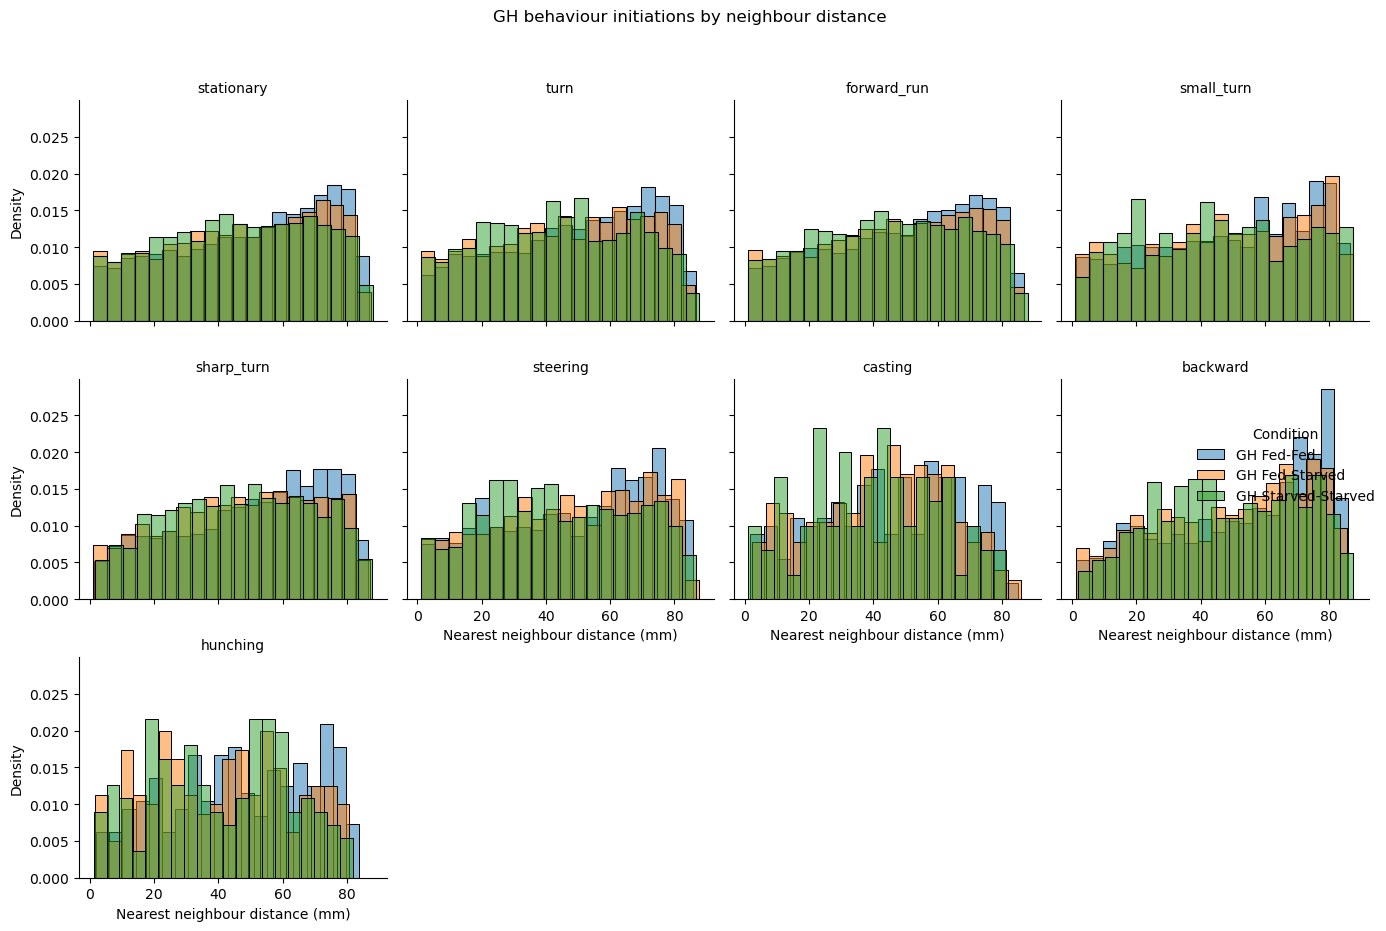

In [ ]:
gh_init_df = gh[gh["is_initiation"]].copy()

gh_init_df = gh_init_df[
    (gh_init_df["closest_node_node_distance"].notna()) &
    (gh_init_df["closest_node_node_distance"] >= 1)
].copy()

gh_init_df = gh_init_df[gh_init_df["behaviour"] != "digging"].copy()  # optional

g = sns.FacetGrid(
    gh_init_df,
    col="behaviour",
    col_wrap=4,
    hue="Condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",
    common_norm=False,
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.suptitle("GH behaviour initiations by neighbour distance", y=1.03)
plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_46288/2551582570.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


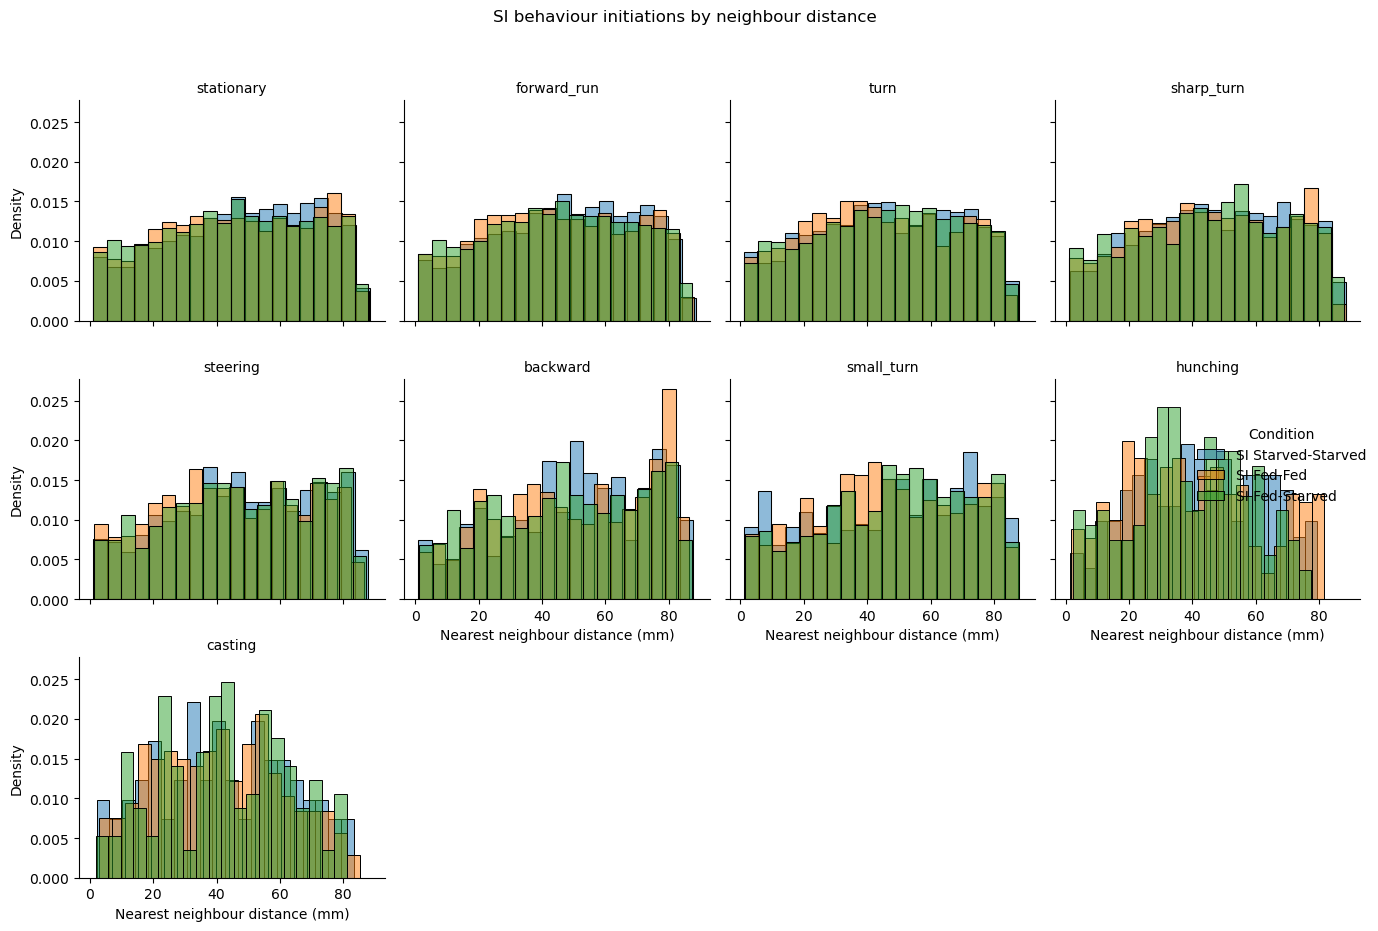

In [ ]:
si_init_df = si[si["is_initiation"]].copy()

si_init_df = si_init_df[
    (si_init_df["closest_node_node_distance"].notna()) &
    (si_init_df["closest_node_node_distance"] >= 1)
].copy()

si_init_df = si_init_df[si_init_df["behaviour"] != "digging"].copy()  # optional

g = sns.FacetGrid(
    si_init_df,
    col="behaviour",
    col_wrap=4,
    hue="Condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",
    common_norm=False,
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.suptitle("SI behaviour initiations by neighbour distance", y=1.03)
plt.tight_layout()
plt.show()